# Laboratory Partial

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

import warnings

warnings.filterwarnings("ignore")

# Exercise 1 (1 point)

A scientist studies how a chemical reaction rate depends on temperature. The Arrhenius equation gives the rate constant $k$ as:

$$k = A\, e^{-\frac{E_a}{RT}}$$

where $A$ is the pre-exponential factor, $E_a$ the activation energy, and $R = 8.3145$ J/(mol·K) the universal gas constant.

Experimental data:

$$\{(k, T)\} = \{(0.0021, 300\,\text{K}),\,(0.0063, 320\,\text{K}),\,(0.0192, 340\,\text{K}),\,(0.0580, 360\,\text{K}),\,(0.1650, 380\,\text{K})\}$$

Estimate $A$ and $E_a$ using:

- Direct pseudoinverse (0.5 points)
- Pseudoinverse via SVD (0.5 points)

In [20]:
R = 8.3145

k = np.array([0.0021, 0.0063, 0.0192, 0.0580, 0.1650])
T = np.array([300, 320, 340, 360, 380])

y = np.log(k)
X = np.column_stack([np.ones(len(T)), 1.0 / T])

L’equació d’Arrhenius es defineix com:

$$
k = A \, e^{-\frac{E_a}{RT}}
$$

Per tal de poder aplicar regressió lineal, linealitzem l’expressió prenent logaritmes naturals:

$$
\ln(k) = \ln(A) - \frac{E_a}{R} \cdot \frac{1}{T}
$$

Aquesta expressió es pot escriure en forma lineal:

$$
y = \theta_0 + \theta_1 x
$$

on:
- $y = \ln(k)$  
- $x = \frac{1}{T}$  
- $\theta_0 = \ln(A)$  
- $\theta_1 = -\frac{E_a}{R}$  

A partir d’aquí, construïm el sistema lineal:

$$
X \theta = y
$$

i estimem els paràmetres $\theta$ utilitzant:
- la pseudoinversa directa  
- la pseudoinversa mitjançant descomposició SVD  

Finalment, recuperem els paràmetres originals:
- $A = e^{\theta_0}$  
- $E_a = -\theta_1 \cdot R$  

---

Per resoldre el sistema lineal $X \theta = y$, cal calcular la **pseudoinversa** de $X$.  

La pseudoinversa estàndard es defineix com:

$$
X^+ = (X^T X)^{-1} X^T
$$

In [21]:
theta = np.linalg.pinv(X) @ y # Fem servir pinv() per calcular la pseudoinversa
lnA_ps, m_ps = theta

A_est_ps = np.exp(lnA_ps)
Ea_est_ps = -m_ps * R

print(f"A (Pseudoinversa) = {A_est_ps:.6f}")
print(f"Ea (Pseudoinversa) = {Ea_est_ps:.2f} J/mol")

A (Pseudoinversa) = 1933079.134407
Ea (Pseudoinversa) = 51770.63 J/mol


Una altra manera estable de calcular la pseudoinversa és utilitzant la **descomposició en valors singulars (SVD)**.  

Si $X$ té la descomposició SVD:

$$
X = U \, \Sigma \, V^T
$$

la pseudoinversa s’expressa com:

$$
X^+ = V \, \Sigma^+ \, U^T
$$

on $\Sigma^+$ és la matriu diagonal amb els inversos dels valors singulars no nuls.

In [22]:
# Pseudoinversa via SVD
def solve_lm_svd(X, t):
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    Sigma_inv = np.diag(1 / s)
    beta_svd = Vt.T @ Sigma_inv @ U.T @ t
    return beta_svd

lnA_svd, m_svd = solve_lm_svd(X, y)

A_est_svd = np.exp(lnA_svd)
Ea_est_svd = -m_svd * R

print(f"A (SVD) = {A_est_svd:.6f}")
print(f"Ea (SVD) = {Ea_est_svd:.2f} J/mol") # Obtenim els mateixos valors que abans

A (SVD) = 1933079.134407
Ea (SVD) = 51770.63 J/mol


# Exercise 2 (2.5 points)

You are studying two species of mice: **Field Mice** and **House Mice**, characterised by:

- **Ear Size** (mm)
- **Tail Length** (cm)

Training data:

| Mouse | Ear Size (mm) | Tail Length (cm) | Species     |
|------:|--------------:|-----------------:|:------------|
|     1 |            25 |             10.0 | Field Mouse |
|     3 |            24 |              9.5 | Field Mouse |
|     4 |            12 |              5.0 | House Mouse |
|     6 |            11 |              4.5 | House Mouse |

Validation data:

| Mouse | Ear Size (mm) | Tail Length (cm) | Species     |
|------:|--------------:|-----------------:|:------------|
|     5 |            13 |              6.0 | House Mouse |
|     2 |            27 |             11.0 | Field Mouse |

In [23]:
# [Ear Size, Tail Length, Bias]
X_train = np.array([[25, 10.0, 1], [24, 9.5, 1], [12, 5.0, 1], [11, 4.5, 1]])
y_train = np.array([1, 1, -1, -1])  # Field=+1, House=-1

X_val = np.array([[13, 6.0, 1], [27, 11.0, 1]])
y_val = np.array([-1, 1])

1. Plot the training and validation data. (0.25 points)

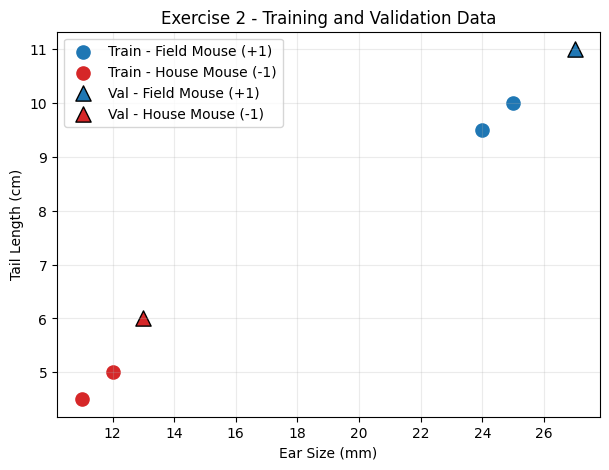

In [24]:
# Plot de train i validation
plt.figure(figsize=(7, 5))

# Training
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c='tab:blue', marker='o', s=90, label='Train - Field Mouse (+1)')
plt.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1],
            c='tab:red', marker='o', s=90, label='Train - House Mouse (-1)')

# Validation
plt.scatter(X_val[y_val == 1, 0], X_val[y_val == 1, 1],
            c='tab:blue', marker='^', s=120, edgecolors='k', label='Val - Field Mouse (+1)')
plt.scatter(X_val[y_val == -1, 0], X_val[y_val == -1, 1],
            c='tab:red', marker='^', s=120, edgecolors='k', label='Val - House Mouse (-1)')

plt.xlabel('Ear Size (mm)')
plt.ylabel('Tail Length (cm)')
plt.title('Exercise 2 - Training and Validation Data')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

2. Complete the vectorised Perceptron Learning rule below. *Vectorised* means no inner loops over samples. (1 point)

Aquest codi implementa l’algorisme del **perceptró** per trobar un vector de pesos $w$ que separi les dades.

Inicialitzem $w = 0$ i iterem fins que no hi hagi errors de classificació. A cada iteració, calculem les prediccions com $scores = X w$ i identifiquem els punts mal classificats amb la condició $y_i (w \cdot x_i) \leq 0$.

Els pesos s’actualitzen sumant totes les mostres mal classificades:

$$
w \leftarrow w + \sum_{i \in \text{mal classificats}} y_i x_i
$$

El procés continua fins que totes les mostres estan correctament classificades, i es compta el nombre d’iteracions necessàries.

In [25]:
w = np.zeros(3)
mistake = True
iters = 0

while mistake:
    mistake = False
    scores = X_train @ w
    misclassified = (y_train * scores) <= 0

    if np.any(misclassified):
        w += np.sum((y_train[misclassified, None] * X_train[misclassified]), axis=0)
        mistake = True
        iters += 1

print("w =", w)
print("iteracions =", iters)

w = [  9.  -15.5 -58. ]
iteracions = 80


In [26]:
y_val_pred = np.sign(X_val @ w)

pd.DataFrame({
    "Mouse": [5, 2],
    "Predicted": np.where(y_val_pred == 1, "Field Mouse", "House Mouse"),
    "True":      ["House Mouse", "Field Mouse"]
})

,Mouse,Predicted,True
0,5,House Mouse,House Mouse
1,2,Field Mouse,Field Mouse


3. Is the vectorised Perceptron appropriate for this problem? (0.25 points)

El perceptró vectoritzat és apropiat per aquest problema, ja que es tracta d’un cas de classificació binària entre Field Mouse i House Mouse. Les característiques disponibles, ear size i tail length, permeten una separació lineal entre les dues classes tal com es pot veure clarament al gràfic anterior.

Aquest algoritme aprèn un classificador lineal i és eficient per conjunts de dades petits com aquest. A més, com que les dades son linealment separables, el perceptró convergeix i troba una solució vàlida.

4. Compute the margin $\gamma$ of your classifier. Check that the number of mistakes satisfies the convergence theorem bound. (0.5 points)

Calculem el marge mínim del classificador obtingut al punt 2:

$$
\gamma = \frac{\min_i \, y_i (w \cdot x_i)}{\|w\|}
$$

i el radi màxim dels punts:

$$
R = \max_i \|x_i\|
$$

Executem el perceptró clàssic i comptem els errors `T`. El teorema estableix:

$$
T \leq \left(\frac{R}{\gamma}\right)^2
$$

Resultats:

- $w = [9, -15.5, -58]$, $\gamma = 0.177$, $R = 26.944$  
- Errors T = 104, Bound = 23151.90 → es compleix T ≤ (R/γ)²

In [27]:
# Fem servir el classificador obtingut al punt 2 
norm_w = np.linalg.norm(w)
signed = y_train * (X_train @ w)
gamma = np.min(signed) / norm_w if norm_w > 0 else 0.0

# Radi màxim dels punts
R = np.max(np.linalg.norm(X_train, axis=1))

# Comptem errors del Perceptró "clàssic" (1 mostra cada cop), que és el del teorema
w_th = np.zeros(3)
T = 0  # nombre d'errors
max_epochs = 1000

for _ in range(max_epochs):
    changed = False
    for xi, yi in zip(X_train, y_train):
        if yi * (w_th @ xi) <= 0:
            w_th = w_th + yi * xi
            T += 1
            changed = True
    if not changed:
        break

bound = (R / gamma) ** 2 if gamma > 0 else np.inf

print(f"w (punt 2) = {w}")
print(f"gamma = {gamma:.6f}")
print(f"R = {R:.6f}")
print(f"T (errors perceptró clàssic) = {T}")
print(f"Bound (R/gamma)^2 = {bound:.6f}")
print("Es compleix T <= (R/gamma)^2 ?", T <= bound)

w (punt 2) = [  9.  -15.5 -58. ]
gamma = 0.177082
R = 26.944387
T (errors perceptró clàssic) = 104
Bound (R/gamma)^2 = 23151.900487
Es compleix T <= (R/gamma)^2 ? True


5. Normalise the data and re-run. Does convergence change? Why? (0.5 points)

In [28]:
# Normalitza amb estadístiques del train
mu = X_train[:, :2].mean(axis=0)
sigma = X_train[:, :2].std(axis=0)

X_train_n = X_train.copy().astype(float)
X_val_n = X_val.copy().astype(float)

X_train_n[:, :2] = (X_train_n[:, :2] - mu) / sigma
X_val_n[:, :2] = (X_val_n[:, :2] - mu) / sigma
X_train_n[:, 2] = 1.0
X_val_n[:, 2] = 1.0

# Re-run perceptró vectoritzat
w_n = np.zeros(3)
mistake = True
iters = 0

while mistake:
    mistake = False
    scores = X_train_n @ w_n
    misclassified = (y_train * scores) <= 0

    if np.any(misclassified):
        w_n += np.sum(y_train[misclassified, None] * X_train_n[misclassified], axis=0)
        mistake = True
        iters += 1

print("w normalitzat =", w_n)
print("iteracions =", iters)

y_val_pred_n = np.sign(X_val_n @ w_n)
print("prediccions val =", y_val_pred_n)

w normalitzat = [3.98821794 3.98014876 0.        ]
iteracions = 1
prediccions val = [-1.  1.]


Després de normalitzar les features (ear size i tail length) utilitzant la mitjana i desviació estàndard del conjunt d’entrenament, el perceptró **convergeix molt més ràpidament**: només cal una iteració per ajustar els pesos correctament.  

La raó és que la normalització escalona les variables, evitant que característiques amb valors més grans o més dispersos dominin el càlcul dels pesos. Això fa que el vector de pesos s’ajusti de manera més equilibrada i estable, millorant l’estabilitat numèrica i accelerant la convergència de l’algorisme.

# Exercise 3 (2.5 points)

A weather station records the number of strong wind gusts (above 50 km/h) per day. You want to predict tomorrow's gust count based on today's observations:

- `Today_Wind`: mean wind speed today (km/h)
- `Today_Temp_Effect`: temperature-driven wind contribution today (km/h)
- `Local_Pressure`: local pressure-driven wind contribution (km/h)
- `Prev_Day_Wind`: mean wind speed yesterday (km/h)

In [29]:
train_data = pd.DataFrame({
    'Today_Wind':        [12.331344, 14.190451, 11.061576, 14.765765, 14.465941,
                           9.693871, 12.531540, 13.949093, 12.392729, 11.970554,
                          13.940820, 12.685564, 13.464540, 12.294099, 11.141531,
                          14.712357, 11.082903, 10.657860, 12.078670, 15.183309],
    'Today_Temp_Effect': [26.44320, 25.76959, 22.69044, 21.47019, 21.09764,
                          19.52647, 21.96041, 16.67302, 33.84478, 29.03981,
                          17.38446, 20.98558, 20.66672, 26.89983, 22.58315,
                          24.26659, 22.85727, 22.78565, 29.84301, 21.87115],
    'Local_Pressure':    [19.549412, 10.353742, 16.753841, 15.371563, 15.647825,
                          16.138918, 13.493030, 14.000378, 11.944274, 11.784626,
                          15.910586, 16.344629, 15.159013, 17.766802, 21.150254,
                          13.526907,  8.072493, 18.017216, 12.872398, 12.935974],
    'Prev_Day_Wind':     [11.95067, 13.79914, 11.43453, 14.50574, 14.63289,
                          10.23066, 12.83317, 14.27677, 13.07936, 12.17283,
                          14.95006, 12.81509, 13.60544, 12.70020, 11.08903,
                          14.99588, 11.50464, 10.32966, 11.32565, 15.45284],
    'Gusts_Tomorrow':    [27, 18, 24, 27, 20, 21, 20, 18, 21, 19,
                          21, 19, 23, 29, 21, 24, 19, 23, 20, 22]
})

valid_data = pd.DataFrame({
    'Today_Wind':        [14.14757, 14.55768, 13.96884, 14.85350, 12.76532,
                          13.18745, 12.84877, 12.84736, 11.27203, 10.25976],
    'Today_Temp_Effect': [22.77486, 19.07548, 14.66029, 21.09887, 27.59498,
                          20.12327, 26.03982, 14.91059, 22.72219, 25.59704],
    'Local_Pressure':    [15.90346, 15.31703, 13.07788, 12.45089, 11.92761,
                          15.35294, 12.15758, 13.52833, 14.23172, 20.53159],
    'Prev_Day_Wind':     [10.535997, 14.876336, 13.670299,  9.200209, 12.850680,
                          22.209957, 15.429354, 13.218108,  8.910818, -1.583915],
    'Gusts_Tomorrow':    [23, 23, 18, 23, 21, 24, 19, 16, 27, 24]
})

print(train_data.head())
print(valid_data.head())

   Today_Wind  Today_Temp_Effect  Local_Pressure  Prev_Day_Wind  \
0   12.331344           26.44320       19.549412       11.95067   
1   14.190451           25.76959       10.353742       13.79914   
2   11.061576           22.69044       16.753841       11.43453   
3   14.765765           21.47019       15.371563       14.50574   
4   14.465941           21.09764       15.647825       14.63289   

   Gusts_Tomorrow  
0              27  
1              18  
2              24  
3              27  
4              20  
   Today_Wind  Today_Temp_Effect  Local_Pressure  Prev_Day_Wind  \
0    14.14757           22.77486        15.90346      10.535997   
1    14.55768           19.07548        15.31703      14.876336   
2    13.96884           14.66029        13.07788      13.670299   
3    14.85350           21.09887        12.45089       9.200209   
4    12.76532           27.59498        11.92761      12.850680   

   Gusts_Tomorrow  
0              23  
1              23  
2             

1. Fit a suitable model to predict `Gusts_Tomorrow`. Report training and validation errors.
2. How can you improve generalisation? Choose and justify the best hyperparameters.

En aquest codi s’ajusta un **model de regressió lineal** per predir la variable `Gusts_Tomorrow` a partir de les features:

`Today_Wind` , `Today_Temp_Effect` , `Local_Pressure` , `Prev_Day_Wind`  

El procés és:

1. Extraiem les matrius de característiques i targets per entrenament i validació.
2. Ajustem el model amb `LinearRegression().fit(X_tr, y_tr)`.
3. Fem prediccions tant sobre el conjunt d’entrenament (`y_tr_pred`) com sobre el de validació (`y_va_pred`).
4. Calculem mètriques d’error per avaluar el model:
   - **MSE**: Mean Squared Error  
   - **RMSE**: Root Mean Squared Error  
   - **MAE**: Mean Absolute Error  

Aquestes mètriques permeten mesurar la precisió del model i comparar el rendiment entre entrenament i validació.

Tal com podem observar, obtenim un valors molt elevats dels errors amb el conjunt de validation. Això és degut a 
que hi ha un clar **overfitting**, per solucionar això en el següent apartat provarem d'afegir regularització (**Ridge/Lasso**).

In [30]:
features = ["Today_Wind", "Today_Temp_Effect", "Local_Pressure", "Prev_Day_Wind"]
target = "Gusts_Tomorrow"

X_tr = train_data[features].values
y_tr = train_data[target].values

X_va = valid_data[features].values
y_va = valid_data[target].values

model = LinearRegression()
model.fit(X_tr, y_tr)

y_tr_pred = model.predict(X_tr)
y_va_pred = model.predict(X_va)

mse_tr = np.mean((y_tr - y_tr_pred) ** 2)
mse_va = np.mean((y_va - y_va_pred) ** 2)

rmse_tr = np.sqrt(mse_tr)
rmse_va = np.sqrt(mse_va)

mae_tr = np.mean(np.abs(y_tr - y_tr_pred))
mae_va = np.mean(np.abs(y_va - y_va_pred))

print("Model: Linear Regression")
print(f"Train   -> MSE: {mse_tr:.4f}, RMSE: {rmse_tr:.4f}, MAE: {mae_tr:.4f}")
print(f"Valid   -> MSE: {mse_va:.4f}, RMSE: {rmse_va:.4f}, MAE: {mae_va:.4f}")

Model: Linear Regression
Train   -> MSE: 5.4335, RMSE: 2.3310, MAE: 2.0097
Valid   -> MSE: 20.7829, RMSE: 4.5588, MAE: 3.6396


In [31]:
alphas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
results = []

for model_name, model_cls in [("Ridge", Ridge), ("Lasso", Lasso)]:
    for a in alphas:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model_cls(alpha=a, max_iter=10000))
        ])

        pipe.fit(X_tr, y_tr)

        y_tr_pred = pipe.predict(X_tr)
        y_va_pred = pipe.predict(X_va)

        mse_tr = np.mean((y_tr - y_tr_pred) ** 2)
        mse_va = np.mean((y_va - y_va_pred) ** 2)

        rmse_tr = np.sqrt(mse_tr)
        rmse_va = np.sqrt(mse_va)

        mae_tr = np.mean(np.abs(y_tr - y_tr_pred))
        mae_va = np.mean(np.abs(y_va - y_va_pred))

        results.append({
            "model": model_name,
            "alpha": a,
            "rmse_train": rmse_tr,
            "rmse_val": rmse_va,
            "mae_train": mae_tr,
            "mae_val": mae_va
        })

res_df = pd.DataFrame(results).sort_values("rmse_val").reset_index(drop=True)
print("Top ten models:")
print(res_df.head(10))

best = res_df.iloc[0]
print("\nBest model:")
print(best)

Top ten models:
   model    alpha  rmse_train  rmse_val  mae_train   mae_val
0  Ridge   10.000    2.478862  2.834004   2.030617  2.278967
1  Lasso    1.000    2.763147  2.947410   2.259749  2.380743
2  Ridge  100.000    2.881303  3.021461   2.362501  2.533897
3  Lasso   10.000    3.026549  3.124100   2.460000  2.640000
4  Lasso  100.000    3.026549  3.124100   2.460000  2.640000
5  Ridge    1.000    2.338220  3.283311   2.007055  2.540803
6  Lasso    0.100    2.344752  3.406845   1.990695  2.707015
7  Lasso    0.010    2.332133  3.794763   2.007290  3.005534
8  Ridge    0.100    2.331209  4.245479   2.009018  3.390376
9  Lasso    0.001    2.331014  4.460390   2.009469  3.561509

Best model:
model            Ridge
alpha             10.0
rmse_train    2.478862
rmse_val      2.834004
mae_train     2.030617
mae_val       2.278967
Name: 0, dtype: object


Per millorar la **generalització** d’un model de regressió lineal, podem utilitzar **regularització** (Ridge o Lasso) per reduir l’overfitting. Això penalitza pesos massa grans i ajuda a que el model tingui un millor rendiment sobre dades de validació.

En el segon codi, es prova una gamma d’**hiperparàmetres `alpha`** per Ridge i Lasso, que controla la força de la penalització:

- **Valors petits de alpha** → penalització dèbil, pot ajustar-se massa a l’entrenament  
- **Valors grans de alpha** → penalització forta, pesos més petits i model més simple  

S’escull el millor `alpha` observant la **RMSE o MAE sobre el conjunt de validació**. Això garanteix que el model tingui **bons resultats tant en entrenament com en validació**, maximitzant la generalització.

Veiem que el model final presenta **Regressió Ridge amb un alpha de 10** i veiem com les metriques que obté tant pel conjunt de train com pel de validation són molt similars cosa que ens indica clarament que no hi ha **overfitting**. 

# Exercise 4 (4 points)

Predict whether a patient will experience disorientation within 12 hours of receiving a 100 mg dose of a new medication.

Predictors: body fat, meat in diet, stress level, blood oxygen, blood sugar.

In [32]:
train_data = pd.DataFrame({
    'fat':   [15.22442, 28.51168,  6.13891, 18.20264, 16.41537, 19.31584,  7.57312, 27.49562,  6.05149, 13.19802, 28.86259, 21.01267, 21.39264, 19.85355, 12.22899, 29.07561, 27.55748, 24.88669, 16.94490, 23.96149, 12.95453, 10.79064, 15.34311,  8.81112,  8.47015, 10.82585, 16.64906,  6.14578, 10.16328,  7.37102, 15.99579, 23.86188,  5.01562, 10.50297, 14.49541, 13.79495,  7.77839, 11.09049,  7.57162,  9.37632,  8.26739, 13.00933,  7.33987, 16.66948, 19.99972, 17.21533, 28.86185, 17.07256,  8.67737, 28.38250,  8.55736, 18.73212, 12.69300, 14.23722,  8.85506,  7.27610, 20.48141, 21.82498, 23.42694, 24.65704, 15.23687, 26.06823, 11.14309, 11.16122,  7.77741, 14.74986, 21.24963, 18.34220, 10.52757, 15.31865, 11.64217, 23.66420, 21.70712, 12.81120, 22.70726, 17.03225, 11.62582, 27.54686, 13.03707, 29.64102,  8.80867, 19.32168, 10.96815, 20.03414, 12.20598,  9.26613,  9.30429, 17.05107, 22.52133, 23.20986, 27.89209, 15.71054,  6.46196, 20.82638, 24.63229, 15.10998, 16.78941, 28.14270, 17.57033,  5.15752,  9.10528, 21.22045, 23.96483,  6.62321,  6.36573, 12.44354, 27.01101, 25.41515, 29.55351,  7.58999, 24.97079, 24.61438,  5.23575, 23.23477, 20.75330,  5.20539, 17.30733],
    'meat':  [121.7750, 141.3636,  94.5035, 184.0134, 135.3303, 148.9152, 233.9748,  92.9359, 242.5512,  65.6625, 253.7704, 128.0282, 179.7012,  56.3817, 297.2696, 284.7846, 221.9019, 254.1195, 234.7579, 137.1799, 183.8853, 118.6363, 258.0269, 238.2775, 291.0381,  70.3666, 263.5912, 131.8993, 196.7397, 282.3377, 271.2832, 188.3285, 155.8659, 227.2595, 153.3264, 191.6835, 172.5159, 269.6685, 268.4875, 195.6849, 181.6475,  72.0908, 134.3738, 273.5837, 109.3074, 106.4546, 129.6236,  93.4960, 143.5423, 207.4364, 245.4558, 272.9740, 243.8519,  60.5270, 118.4378, 262.6169, 239.7838, 164.4804, 232.4079, 238.0094, 249.7059,  72.5805, 125.1294, 191.7799, 234.1551, 264.3619,  79.3328,  68.7392,  89.2920, 211.7643,  93.3794, 120.7506, 155.1087, 228.6887, 257.8055, 187.6542, 180.5839, 113.4552, 208.7001, 184.8902, 157.1533, 138.9404, 261.2334,  55.7861, 144.1111,  96.4683, 157.2351, 207.6934, 146.1142, 235.6348,  55.7137, 268.7206, 281.1197, 199.3384, 172.4593, 272.0929,  59.1761, 178.4453, 213.3570, 253.2783, 251.8748, 252.1530, 114.7003, 100.8543, 120.7832, 283.4241, 172.3570, 151.9077,  75.9279, 120.1413, 114.8112, 167.6705, 141.4614,  61.7484, 115.6991, 169.4555, 216.9101],
    'stress':[16.01848, 84.77392, 47.78868, 77.36921, 44.05331, 50.69977,  1.91910, 77.36860, 64.14626, 46.84321, 27.92238, 58.55656, 81.12373, 45.54890, 26.88034, 23.12309, 54.32329, 13.02881, 54.79943, 14.92442, 42.68856, 44.77301, 45.68868, 24.24571,  7.58608, 39.12951,  1.31082, 70.88554, 27.64399, 17.30430, 56.19632, 78.84094, 80.04764, 62.89278, 27.14090, 41.98642, 35.54347, 39.23313, 75.93357, 48.01264, 80.62479, 73.87485, 62.45530, 28.86901, 80.09179, 21.70480, 74.42385, 86.66537, 66.05323,  7.22866, 24.43082, 42.18101, 71.86118, 13.83901, 93.10996, 56.83380, 54.02562, 70.29795, 56.77484, 28.80103, 40.53639, 21.71838, 32.82387, 91.89548, 52.87654, 37.19788, 45.92408,  7.24691, 28.69576, 14.94125, 97.24320, 91.63057, 21.66621, 21.05232, 67.90228, 13.49964, 38.74983, 59.42730, 55.50781, 44.94114, 96.85509, 38.51986, 85.85914, 48.90915, 15.76628, 78.53486, 54.21883, 41.65473, 81.36684, 11.16880, 53.09357, 27.75601, 58.87063, 44.02418, 86.59671, 24.45707, 98.15432, 24.87264, 97.28035, 72.52280, 56.61824, 39.21965, 20.20875, 73.55584, 34.61270, 81.57680, 84.81077, 30.33252, 77.05970, 73.34485, 56.90488,  2.62808, 48.61272, 83.66601, 72.86645, 13.65023,  9.96219],
    'oxygen':[83.6896, 90.8647, 86.6990, 87.5413, 87.9056, 76.6831, 82.6051, 82.5995, 81.4134, 82.6705, 75.7428, 91.9361, 91.9372, 82.5524, 89.3152, 95.0033, 90.8430, 82.4272, 77.5004, 81.2130, 97.9481, 84.2903, 79.9335, 90.2899, 78.3200, 71.5857, 82.7728, 99.0940, 79.5550, 79.3722, 95.9518, 78.2977, 80.7598, 92.3828, 70.8888, 77.6988, 84.9405, 89.6007, 94.3718, 80.4590, 93.8067, 79.8347, 75.3501, 92.2405, 89.1756, 77.6580, 94.6172, 94.1134, 84.0870, 86.7187, 81.7985, 88.2654, 71.7628, 84.0713, 87.4516, 75.6066, 93.8296, 82.6908, 89.6314, 77.7251, 94.8722, 84.0087, 81.8339, 81.4814, 70.9591, 85.6434, 78.2543, 82.0019, 81.7155, 82.7188, 78.5927, 92.3585, 76.1946, 86.1706, 99.8912, 71.0597, 85.7684, 98.5851, 72.4986, 77.7978, 84.6447, 75.6327, 91.3910, 83.8360, 87.8448, 99.6956, 88.4623, 78.1923, 98.3687, 86.6992, 75.9144, 83.4023, 98.1105, 70.1609, 84.9976, 82.0313, 83.4262, 90.5000, 97.2617, 89.1730, 88.0338, 84.1598, 74.8289, 98.9880, 90.3236, 77.2495, 95.0857, 79.9657, 89.3421, 98.7585, 85.3084, 74.6579, 95.3755, 90.0962, 88.5327, 87.4766, 85.5540],
    'sugar': [ 86.4098, 124.2110, 137.7977, 119.2165,  94.4018, 136.9460, 179.1374,  91.0309,  96.6626, 106.0197,  70.3889, 179.7458,  82.2624, 133.4980, 115.7982, 133.1609, 133.5399,  94.5221, 151.0157, 137.3644, 175.5863, 151.9320, 117.8817, 171.0932, 169.7367, 159.7064,  91.9728, 134.9433,  84.0553, 163.6432, 172.7028,  84.0571, 114.0314, 154.4359, 127.4085, 176.2366,  75.3884,  86.8639, 121.1025, 104.6850,  86.9146, 104.1532, 115.7383, 127.4459, 139.2826, 116.7186, 176.0146, 144.9098, 162.1275, 149.2690,  94.1815, 153.9417,  99.6936, 165.4600, 163.5029, 127.6326,  88.1005,  85.1849,  86.4693, 159.2210,  89.8967,  86.7809, 139.7575,  87.7186, 110.5968, 103.2440, 139.3319, 179.6168, 178.9080, 151.9837, 118.0425, 116.9203, 160.2858, 142.7013,  70.9589,  73.1000, 163.0031, 152.0505,  88.9258, 143.6688, 114.3601,  84.1183, 160.2181, 156.7157, 147.8048, 132.0036, 101.1089, 113.1262,  81.3519, 161.3834,  90.2796, 164.4737, 141.3023, 176.6171,  95.9863, 107.4494,  76.4230, 145.6844,  98.4506, 104.3051,  73.3602,  75.5183, 109.5803, 129.2459, 137.5516,  95.0392, 116.3993,  96.2021, 102.0794, 166.4035, 164.3029, 122.5013, 168.3654, 138.3177, 149.5037, 143.8684, 105.8116],
    'disorientation': [0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
})

val_data = pd.DataFrame({
    'fat':   [ 6.38255, 10.94374, 13.84965, 26.42214, 26.34408, 12.39739, 22.59980, 27.87659, 12.15713, 23.44494, 17.31416, 15.36838,  7.98512, 18.15074, 29.58375, 17.87680,  9.07676, 29.64885, 25.88138,  8.59543, 27.41847, 14.08251, 24.59866,  5.44415, 15.54612, 29.09608, 24.36479, 24.22985, 12.05546, 10.26218, 29.42748, 12.40755, 23.14958,  7.94785, 29.78091, 29.65136, 27.63274, 14.88622, 16.24506],
    'meat':  [271.0334,  81.5207, 197.4754, 190.4189, 222.1803, 127.8177, 297.7586, 233.4880, 242.9774, 165.7438, 193.0184, 290.6053, 234.0835, 203.1809, 274.5902, 297.9363, 228.7834, 159.0119, 272.2554, 156.1130, 211.8605, 204.4815, 117.7039,  78.5636,  85.1615, 218.3887,  53.2603,  87.1484, 124.4308, 105.7203, 191.4136, 239.1625, 217.4009,  62.7200, 249.4757, 280.9248, 263.0911, 217.0809, 177.8286],
    'stress':[23.68726, 25.51057, 54.80433,  3.39015, 80.61095, 33.77528, 35.71064, 64.14732, 32.03521, 58.14332, 17.03690, 30.22353, 45.65182, 38.43425, 29.10830, 13.13782,  2.48171, 47.55582, 48.88076, 64.88825, 83.69779, 23.34955, 29.88560, 58.55671, 33.92215, 82.35256, 37.39821,  7.58029, 86.95323, 23.48996, 99.30155, 67.81977, 43.54868,  5.32594, 23.71979, 23.32397,  6.17263, 24.41251, 75.81855],
    'oxygen':[90.6786, 83.4781, 88.0812, 70.1383, 99.8498, 82.1939, 96.0862, 93.0943, 85.0223, 97.7759, 79.4738, 80.1829, 84.4494, 82.4798, 89.2735, 83.8589, 72.1404, 87.3874, 98.1567, 87.2457, 72.6928, 85.0342, 76.6977, 96.5892, 78.4751, 98.0727, 82.4523, 77.3652, 81.7555, 88.0632, 86.2382, 99.7247, 77.6137, 73.3715, 86.0733, 83.3149, 74.7207, 86.8613, 86.5207],
    'sugar': [140.1384, 142.9693,  92.1768, 134.5545, 146.4577, 128.1117, 146.8320, 130.9489,  93.2212, 140.0033,  78.0529, 141.4933,  87.1985, 170.1158, 132.2852, 101.0591, 150.2976,  77.2895, 116.4625, 130.4727,  96.3994, 123.0886,  98.9132, 143.0732, 166.6565,  97.2321, 171.7536, 111.5294, 157.3796, 148.1768, 132.2279,  71.1127,  98.2646, 140.9932, 169.1219, 150.5554,  94.6809, 158.3037, 104.3649],
    'disorientation': [1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1]
})

print(train_data.head())

        fat      meat    stress   oxygen     sugar  disorientation
0  15.22442  121.7750  16.01848  83.6896   86.4098               0
1  28.51168  141.3636  84.77392  90.8647  124.2110               1
2   6.13891   94.5035  47.78868  86.6990  137.7977               0
3  18.20264  184.0134  77.36921  87.5413  119.2165               0
4  16.41537  135.3303  44.05331  87.9056   94.4018               0


Using all the concepts and models covered so far, build the best solution you can.

**Note:** you are evaluated on your **process** (including hyperparameter search), not just the final model.

## Introducció i mètriques

En aquest apartat hem decidit avaluar dos models diferents sobre el conjunt de dades i escollir aquell que obtingui millors resultats. Com que es tracta d'una predicció binària, hem provat una **Regressió Logística** i una **MLP**, que són dos dels models que hem vist a classe. Per definir la millor configuració d’hiperparàmetres per a cada model hem creat un **pipeline**, que explicarem més endavant, i hem treballat sobre un conjunt de **mètriques específiques** per al context del problema, ja que es tracta d’un estudi mèdic.

El primer que hem observat és que les classes estan lleugerament desbalancejades: tant al conjunt d’entrenament com al de validació, la distribució és del tipus 65-35, amb major quantitat de valors negatius. Per això hem decidit **no utilitzar l’accuracy**, ja que podria donar valors poc representatius de la qualitat real de les prediccions; un model que predigui sempre la classe negativa obtindria un 65% d’accuracy, tot i que en realitat seria un model poc útil.  

En comptes d’això, ens hem guiat per l’**AUC**, ja que aquesta mètrica no depèn ni del balanceig de classes ni del threshold escollit. La **F1**, en canvi, depèn molt del threshold i podria no reflectir el rendiment real dels models si variem aquest valor; un model que funcioni millor amb un threshold superior o inferior podria veure’s penalitzat injustament. L’AUC té en compte tots els thresholds i, per tant, no es veu afectada per aquestes variacions.

Tal com acabem de mencionar, també volem **experimentar amb el threshold** per trobar l’òptim per al nostre problema, ja que al ser les classes lleugerament desbalancejades, el threshold per defecte (0.5) probablement no serà l’adequat. Finalment, cal destacar que preferim models que minimitzin els **falsos negatius**, és a dir, que maximitzin el **recall**. Ho fem així perquè es tracta d’un cas mèdic: si ens hem d’equivocar, preferim predir que algú patirà un mareig quan en realitat no passi res, que no pas al contrari, ja que les conseqüències podrien ser molt més greus en aquest segon cas.

Les funcions definides a la següent cel·la ens permeten obtenir les mètriques esmentades anteriorment (i algunes més per a l’anàlisi de resultats), així com explorar el threshold i preparar les dades.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, log_loss
)

np.random.seed(42)

# 1) Data
features = ["fat", "meat", "stress", "oxygen", "sugar"]
target   = "disorientation"

X_train = train_data[features].values
y_train = train_data[target].values
X_val   = val_data[features].values
y_val   = val_data[target].values

print("Train shape:", X_train.shape, "  Val shape:", X_val.shape)
print("Train positives:", y_train.sum(), "/", len(y_train),
      f"  ({y_train.mean()*100:.1f}%)")
print("Val positives  :", y_val.sum(),   "/", len(y_val),
      f"  ({y_val.mean()*100:.1f}%)")


# Métriques
def metrics_from_prob(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "acc"      : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall"   : recall_score(y_true, y_pred, zero_division=0),
        "f1"       : f1_score(y_true, y_pred, zero_division=0),
        "auc"      : roc_auc_score(y_true, y_prob),
        "logloss"  : log_loss(y_true, y_prob, labels=[0, 1]),
    }


# Threshold
def best_threshold(y_true, y_prob):
    """Returns the threshold in [0.1, 0.9] that maximises val F1."""
    thresholds = np.linspace(0.1, 0.9, 81)
    best_thr, best_f1 = 0.5, -1
    for thr in thresholds:
        f1 = f1_score(y_true, (y_prob >= thr).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr

Train shape: (117, 5)   Val shape: (39, 5)
Train positives: 42 / 117   (35.9%)
Val positives  : 15 / 39   (38.5%)


## Estructura del pipeline

Tant per a la regressió logística com per al MLP, hem construït un **pipeline general** que segueixen els 2 models. Aquest pipeline serveix com a **base** per a que l'entrenament i la validació dels 2 models es faci de manera semblant i així poder comparar els resultats de manera justa. En general, el pipeline d'un model concret segueix la següent estructura:

1) **Definició d'hiperparàmetres**: primerament, indiquem per **quins hiperparàmetres i amb quins valors** volem fer el procés d'entrenament. Ho definim com un diccionari amb el nom de l'hiperparàmetre i una llista amb els valors a provar.

2) **Millors hiperparàmetres**: explorem **totes les possibles combinacions** a partir del hiperparàmetres escollits i guardem els resultats per cada combinació.

3) **Millor model**: establim **l'AUC com a mètrica principal** per triar el millor model. Ordenem els resultats segons l'AUC i **triem la millor configuració** segons aquesta mètrica.

4) **Millor threshold**: un cop reentrenat el model amb la millor configuració trobada, **busquem el millor threshold per a aquest model**.

5) **Gràfics**: finalment, un cop obtinguts tots els resultats, **els visualitzem amb diferents gràfics**.

## Regressió Logística

El primer model que implementarem serà una **regressió logística**. Al pipeline definim l’exploració dels següents **hiperparàmetres**:  

- **Penalty**: Indica el tipus de regularització que utilitzarem (`l1` o `l2`, equivalent a Lasso o Ridge), útil per reduir l’overfitting.  
- **C**: Controla la força de la regularització; és la inversa del valor `alpha` que hem vist anteriorment. A major `C`, la regularització és més dèbil i el model pot ajustar-se més a les dades.  
- **Solver**: Algorisme utilitzat per optimitzar la funció de cost del model. Utilitzem els més habituals i robusts: `liblinear` i `lbfgs`.  
- **Class_Weight**: Permet aplicar un balanceig de classes si les dades estan desbalancejades. Tot i que el nostre desbalanceig no és molt greu, convé provar-ho per veure si s’obtenen millors resultats.  

Un cop definits tots els hiperparàmetres, fem una **exploració de totes les combinacions** possibles. Cal tenir en compte que algunes combinacions no són vàlides segons el tipus de solver i s’han d’evitar.  

Al pipeline també hi incloem un **escalat de les dades** i un **màxim d’iteracions** fixat. Tal com hem explicat abans, la cerca es realitza segons l’**AUC** (o **F1** si hi ha empat, o **AUC del train** si hi ha empat), i un cop seleccionat el millor model, determinem quin **threshold** proporciona millors resultats.  

A continuació, farem un **anàlisi dels resultats obtinguts** per comprendre el rendiment del model i l’impacte dels diferents hiperparàmetres.


=== Logistic top configs (sorted by val AUC) ===
            C class_weight penalty     solver  train_auc   val_auc  train_f1    val_f1  train_acc   val_acc   gap_auc
0  100.000000          NaN      l2  liblinear   0.714603  0.722222  0.461538  0.222222   0.700855  0.641026 -0.007619
1  100.000000          NaN      l2      lbfgs   0.714286  0.722222  0.461538  0.222222   0.700855  0.641026 -0.007937
2   35.111917          NaN      l2  liblinear   0.713968  0.722222  0.461538  0.222222   0.700855  0.641026 -0.008254
3   35.111917          NaN      l2      lbfgs   0.713968  0.722222  0.461538  0.222222   0.700855  0.641026 -0.008254
4  100.000000          NaN      l1  liblinear   0.713968  0.722222  0.461538  0.222222   0.700855  0.641026 -0.008254
5    4.328761          NaN      l1  liblinear   0.716190  0.722222  0.461538  0.222222   0.700855  0.641026 -0.006032
6    1.519911          NaN      l2  liblinear   0.714603  0.722222  0.461538  0.222222   0.700855  0.641026 -0.007619
7    4

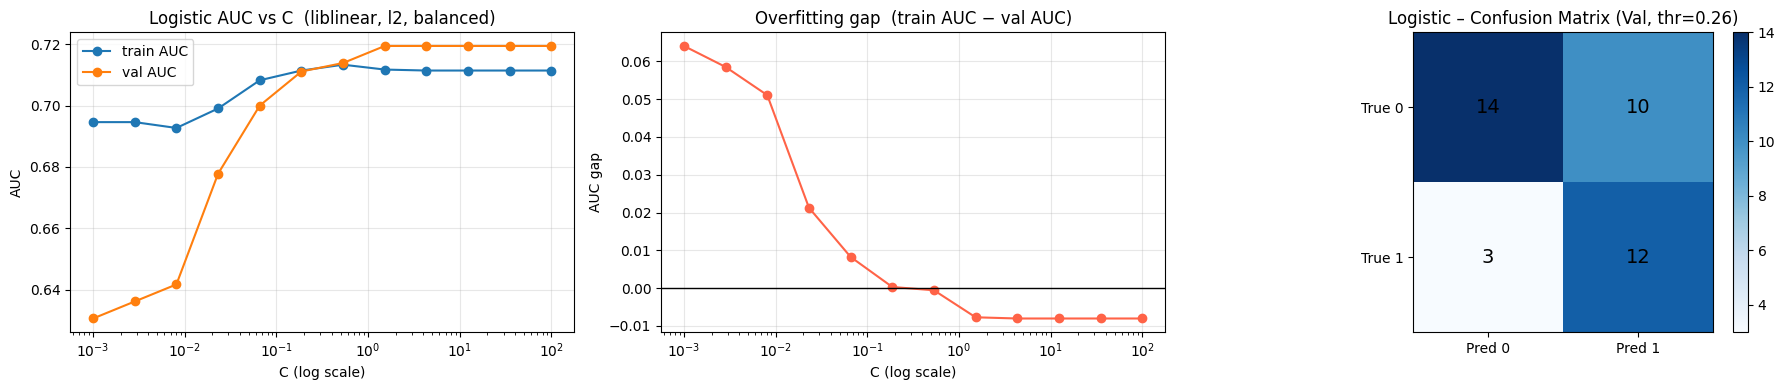

In [34]:
# Regressió Logística

log_grid = {
    "penalty"     : ["l1", "l2"],
    "C"           : np.logspace(-3, 2, 12),
    "solver"      : ["liblinear", "lbfgs"], 
    "class_weight": [None, "balanced"],
}

log_results = []
for cfg in ParameterGrid(log_grid):
    # Evitem combinacions invàlides
    if cfg["solver"] == "lbfgs" and cfg["penalty"] != "l2":
        continue

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, random_state=42, **cfg)),
    ])
    pipe.fit(X_train, y_train)
    p_tr = pipe.predict_proba(X_train)[:, 1]
    p_va = pipe.predict_proba(X_val)[:, 1]
    m_tr = metrics_from_prob(y_train, p_tr)
    m_va = metrics_from_prob(y_val,   p_va)
    log_results.append({
        **cfg,
        "train_auc": m_tr["auc"], "val_auc": m_va["auc"],
        "train_f1" : m_tr["f1"],  "val_f1" : m_va["f1"],
        "train_acc": m_tr["acc"], "val_acc": m_va["acc"],
        "gap_auc"  : m_tr["auc"] - m_va["auc"],
    })

# Ordenem per AUC
log_df = pd.DataFrame(log_results).sort_values(
    by=["val_auc", "val_f1","train_auc"], ascending=False
).reset_index(drop=True)

print("\n=== Logistic top configs (sorted by val AUC) ===")
print(log_df.head(10).to_string())

# Millor config
best_log_row = log_df.iloc[0]
best_log_cfg = best_log_row[["penalty", "C", "solver", "class_weight"]].to_dict()

for key, value in best_log_cfg.items():
    if pd.isna(value):
        best_log_cfg[key] = None

print("\nBest logistic config:", best_log_cfg)

best_log = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=42, **best_log_cfg)),
])
best_log.fit(X_train, y_train)
p_train_log = best_log.predict_proba(X_train)[:, 1]
p_val_log   = best_log.predict_proba(X_val)[:, 1]

# Obtenim el millor threshold
thr_log = best_threshold(y_val, p_val_log)
print(f"Optimal threshold (log): {thr_log:.2f}")

m_train_log = metrics_from_prob(y_train, p_train_log, thr=thr_log)
m_val_log   = metrics_from_prob(y_val,   p_val_log,   thr=thr_log)
print("Train:", m_train_log)
print("Val  :", m_val_log)

# Plots
best_pen = best_log_row["penalty"]
curve_df = log_df[
    (log_df["solver"] == "liblinear") &
    (log_df["penalty"] == best_pen) &
    (log_df["class_weight"] == "balanced")
].sort_values("C")

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ax[0].plot(curve_df["C"], curve_df["train_auc"], marker="o", label="train AUC")
ax[0].plot(curve_df["C"], curve_df["val_auc"],   marker="o", label="val AUC")
ax[0].set_xscale("log")
ax[0].set_title(f"Logistic AUC vs C  (liblinear, {best_pen}, balanced)")
ax[0].set_xlabel("C (log scale)"); ax[0].set_ylabel("AUC")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(curve_df["C"], curve_df["gap_auc"], marker="o", color="tomato")
ax[1].axhline(0, color="black", linewidth=1)
ax[1].set_xscale("log")
ax[1].set_title("Overfitting gap  (train AUC − val AUC)")
ax[1].set_xlabel("C (log scale)"); ax[1].set_ylabel("AUC gap")
ax[1].grid(alpha=0.3)

cm_log = confusion_matrix(y_val, (p_val_log >= thr_log).astype(int))
im = ax[2].imshow(cm_log, cmap="Blues")
ax[2].set_title(f"Logistic – Confusion Matrix (Val, thr={thr_log:.2f})")
ax[2].set_xticks([0, 1]); ax[2].set_xticklabels(["Pred 0", "Pred 1"])
ax[2].set_yticks([0, 1]); ax[2].set_yticklabels(["True 0", "True 1"])
for i in range(2):
    for j in range(2):
        ax[2].text(j, i, cm_log[i, j], ha="center", va="center", fontsize=14)
plt.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Avaluació resultats Regressió Logística

El primer que observem és que els **10 millors models** presenten els mateixos valors de **val_auc** i **val_f1** per al conjunt de validació. Això és degut al fet que estem treballant amb un **dataset molt petit**, de manera que tots els models acaben obtenint resultats molt similars. Per tant, en triar el millor model, estem seleccionant essencialment el que presenta **major AUC al conjunt de train**, o dit d’una altra manera, el que té menys overfitting. També veiem que aquests 10 millors models no utilitzen **balanceig de classes** i que la majoria fan servir **regularització L2** en lloc de L1.

Si ens fixem en el model guanyador, té una **C molt alta**, és a dir, s’aplica **poca regularització**. Aplicar més regularització probablement hauria donat els mateixos resultats o pitjors. Aquest model **no mostra overfitting**. Avaluant el **millor threshold**, obtenim **0.26**, que permet classificar com a positius alguns casos que abans es marcaven com a negatius, millorant així el **F1**, l’objectiu principal

Si mirem les **gràfiques d’overfitting**, el punt seleccionat correspon al **valor màxim d’AUC possible** per al conjunt de validació. Si augmentem la **C**, no millora. Si la disminuïm, hi ha un interval amb **poca regularització** on el model empitjora lleugerament, tot i que sense overfitting. Quan **C** disminueix encara més, apareix **overfitting clar**.

La **matriu de confusió** mostra pocs **falsos negatius** i bastants **falsos positius**. Tot i que es podria millorar, és un resultat acceptable, ja que en aquest context mèdic **preferim falsos positius abans que falsos negatius**.

## Multilayer Perceptron (MLP)

El segon model a implementar serà un **perceptró multicapa**. Al pipeline definim l'exploració del següents **hiperparàmetres**:

- **Solver**: Defineix l'algorisme d'optimització del model. En aquest cas, hem decidit probar dos mètodes per explorar diferents comportaments: `adam` i `sgd`. Els hem separat en 2 diccionaris per poder definir alguns hiperparàmetres específics de cada mètode.

- **Activation**: Funció d'activació de les capes ocultes, concretament provarem 3: `relu`, `tanh` i `logistic`.

- **Hidden_Layer_Sizes**: Defineix l'arquitectura de la xarxa `(nombre_de_neurones, nombre_de_capes)` per intentar evitar underfitting o overfitting.

- **Alpha**: Paràmetre de regularització `l2`. Penalitza els pessos massa grans, reduïnt així l'overfitting.

- **Learning_Rate_Init**: Taxa d'aprenentatge inicial, que determina que tant ràpid i que tant estable és el model a l'hora de convergir.

- **Batch_Size**: Determina la mida dels lots (*batches*) durant l'entrenament.

- _Paràmetres espcífics d'`adam`_: **Beta_1** i **Beta_2**, que controlen quant "recorda" el model la direcció recent del gradient i la mida dels gradients, respectivament.

- _Paràmetres específics d'`sgd`_: **Learning_Rate**, que diu com evoluciona la velocitat d'aprenentatge;   **Momentum**, que afegeix "inèrcia" al moviment; i **Nesterovs_Momentum**, que és una versió millorada del momentum.

De la mateixa manera que amb la regressió logística, un cop definits tots els hiperparàmetres, fem una **exploració de totes les configuracions** i guardem les mètriques de cada entrenament.

Al pipeline també hi incloem **l'escalat de les dades**, **early stopping** (que atura l'entrenament quan el rendiment en validació deixa de millorar), i un **màxim d'iteracions** fixat per evitar entrenaments innecessàriament llargs.

La cerca es realitza segons l'**AUC** (o **F1** si hi ha empat) i, després de seleccionar el model definitiu, busquem quin **threshold** dona millors resultats.

Seguidament farem un **anàlisi de resultats**.


=== MLP top configs (sorted by val AUC) ===
  activation    alpha  batch_size  beta_1  beta_2 hidden_layer_sizes  learning_rate_init solver  train_auc   val_auc  train_f1    val_f1   gap_auc  train_logloss  val_logloss  n_iter learning_rate  momentum nesterovs_momentum
0       tanh  0.00010          32    0.80   0.999           (64, 32)              0.0005   adam   0.729524  0.747222  0.468750  0.222222 -0.017698       0.584542     0.604583      92           NaN       NaN                NaN
1       tanh  0.00001          32    0.95   0.999           (64, 32)              0.0005   adam   0.709841  0.725000  0.444444  0.222222 -0.015159       0.595243     0.611494      65           NaN       NaN                NaN
2       tanh  0.00010          32    0.95   0.990              (16,)              0.0005   adam   0.695873  0.688889  0.609524  0.571429  0.006984       0.666457     0.652948     113           NaN       NaN                NaN
3       tanh  0.00100          16     NaN     NaN  

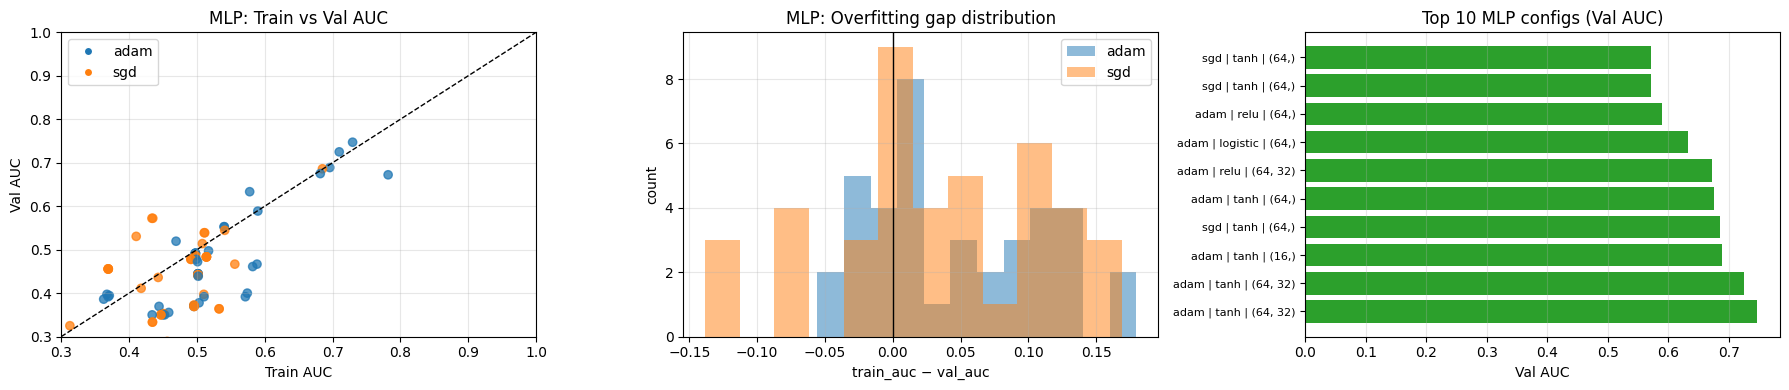

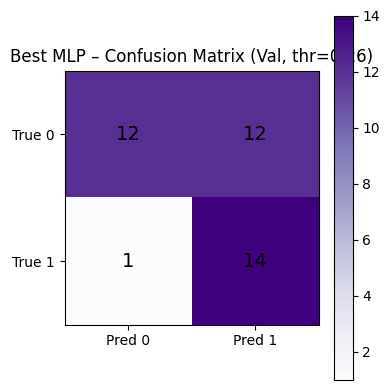

In [35]:
# Multilayer Perceptron

mlp_space_adam = {
    "solver"            : ["adam"],
    "activation"        : ["relu", "tanh", "logistic"],
    "hidden_layer_sizes": [(16,), (32,), (64,), (32, 16), (64, 32)],
    "alpha"             : [1e-5, 1e-4, 1e-3],
    "learning_rate_init": [1e-4, 5e-4, 1e-3],
    "beta_1"            : [0.8, 0.9, 0.95],
    "beta_2"            : [0.99, 0.999],
    "batch_size"        : [16, 32],
}

mlp_space_sgd = {
    "solver"            : ["sgd"],
    "activation"        : ["relu", "tanh"],
    "hidden_layer_sizes": [(16,), (32,), (64,), (32, 16), (64, 32)],
    "alpha"             : [1e-5, 1e-4, 1e-3],
    "learning_rate_init": [1e-4, 5e-4, 1e-3],
    "learning_rate"     : ["constant", "adaptive"],
    "momentum"          : [0.0, 0.5, 0.9],
    "nesterovs_momentum": [False, True],
    "batch_size"        : [16, 32],
}

# Juntem tot el que volem provar i ho barregem
all_cfgs = list(ParameterGrid(mlp_space_adam)) + list(ParameterGrid(mlp_space_sgd))
np.random.shuffle(all_cfgs)

# Agafem únicament les 80 primeres configuracions (després de fer el shuffle) per simplificar
N_TRIALS = 80
cfgs = all_cfgs[:N_TRIALS]

mlp_results = []
for i, cfg in enumerate(cfgs, 1):
    try:
        clf = MLPClassifier(
            random_state=42, max_iter=700,
            early_stopping=True, validation_fraction=0.2,
            n_iter_no_change=25, **cfg,
        )
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
        pipe.fit(X_train, y_train)

        p_tr = pipe.predict_proba(X_train)[:, 1]
        p_va = pipe.predict_proba(X_val)[:, 1]
        m_tr = metrics_from_prob(y_train, p_tr)
        m_va = metrics_from_prob(y_val,   p_va)

        mlp_results.append({
            **cfg,
            "train_auc"  : m_tr["auc"],   "val_auc"  : m_va["auc"],
            "train_f1"   : m_tr["f1"],    "val_f1"   : m_va["f1"],
            "gap_auc"    : m_tr["auc"] - m_va["auc"],
            "train_logloss": m_tr["logloss"],
            "val_logloss"  : m_va["logloss"],
            "n_iter"     : pipe.named_steps["clf"].n_iter_,
        })
    except Exception:
        continue

# Ordenem per AUC
mlp_df = pd.DataFrame(mlp_results).sort_values(
    by=["val_auc", "val_f1"], ascending=False
).reset_index(drop=True)

print("\n=== MLP top configs (sorted by val AUC) ===")
print(mlp_df.head(10).to_string())
print("\nConfigs avaluades:", len(mlp_df), "/", N_TRIALS)

# Millor config
best_mlp_row = mlp_df.iloc[0]
best_mlp_cfg = best_mlp_row[[
    "solver", "activation", "hidden_layer_sizes", "alpha",
    "learning_rate_init", "batch_size",
]].to_dict()

if best_mlp_cfg["solver"] == "adam":
    best_mlp_cfg["beta_1"] = best_mlp_row["beta_1"]
    best_mlp_cfg["beta_2"] = best_mlp_row["beta_2"]
else:
    best_mlp_cfg["learning_rate"]       = best_mlp_row["learning_rate"]
    best_mlp_cfg["momentum"]            = best_mlp_row["momentum"]
    best_mlp_cfg["nesterovs_momentum"]  = best_mlp_row["nesterovs_momentum"]

print("\nBest MLP config:", best_mlp_cfg)

best_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        random_state=42, max_iter=900,
        early_stopping=True, validation_fraction=0.2,
        n_iter_no_change=30, **best_mlp_cfg,
    )),
])
best_mlp.fit(X_train, y_train)

p_train_mlp = best_mlp.predict_proba(X_train)[:, 1]
p_val_mlp   = best_mlp.predict_proba(X_val)[:, 1]

# Obtenim el millor threshold
thr_mlp = best_threshold(y_val, p_val_mlp)
print(f"Optimal threshold (MLP): {thr_mlp:.2f}")

m_train_mlp = metrics_from_prob(y_train, p_train_mlp, thr=thr_mlp)
m_val_mlp   = metrics_from_prob(y_val,   p_val_mlp,   thr=thr_mlp)
print("Train:", m_train_mlp)
print("Val  :", m_val_mlp)

# Plots
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

colors = mlp_df["solver"].map({"adam": "tab:blue", "sgd": "tab:orange"}).values
ax[0].scatter(mlp_df["train_auc"], mlp_df["val_auc"], c=colors, alpha=0.75)
ax[0].plot([0.3, 1.0], [0.3, 1.0], "k--", linewidth=1)
ax[0].set_xlim(0.3, 1.0); ax[0].set_ylim(0.3, 1.0)
ax[0].set_xlabel("Train AUC"); ax[0].set_ylabel("Val AUC")
ax[0].set_title("MLP: Train vs Val AUC")
ax[0].grid(alpha=0.3)
ax[0].legend(handles=[
    Line2D([0],[0], marker="o", color="w", markerfacecolor="tab:blue",  label="adam"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="tab:orange", label="sgd"),
], loc="upper left")

for solver, color in [("adam", "tab:blue"), ("sgd", "tab:orange")]:
    vals = mlp_df.loc[mlp_df["solver"] == solver, "gap_auc"].values
    if len(vals):
        ax[1].hist(vals, bins=12, alpha=0.5, label=solver, color=color)
ax[1].axvline(0, color="black", linewidth=1)
ax[1].set_title("MLP: Overfitting gap distribution")
ax[1].set_xlabel("train_auc − val_auc"); ax[1].set_ylabel("count")
ax[1].legend(); ax[1].grid(alpha=0.3)

top10   = mlp_df.head(10).copy()
labels  = [f"{r['solver']} | {r['activation']} | {r['hidden_layer_sizes']}"
           for _, r in top10.iterrows()]
ax[2].barh(range(len(top10))[::-1], top10["val_auc"].values[::-1], color="tab:green")
ax[2].set_yticks(range(len(top10))[::-1])
ax[2].set_yticklabels(labels[::-1], fontsize=8)
ax[2].set_title("Top 10 MLP configs (Val AUC)")
ax[2].set_xlabel("Val AUC"); ax[2].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

cm_mlp = confusion_matrix(y_val, (p_val_mlp >= thr_mlp).astype(int))
plt.figure(figsize=(4, 4))
plt.imshow(cm_mlp, cmap="Purples")
plt.title(f"Best MLP – Confusion Matrix (Val, thr={thr_mlp:.2f})")
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_mlp[i, j], ha="center", va="center", fontsize=14)
plt.colorbar(); plt.tight_layout(); plt.show()

## Avaluació resultats Multilayer Perceptron

Primerament, podem obervar que els 10 millors models MLP tenen valors de val_auc **relativament propers**, tot i que no tant propers com la regressió logística, amb el millor resultat a **0.7472**. També veiem que a la part alta del rànquing predomina clarament **`adam` amb activació `tanh`**, mentre que algunes configuracions amb solver `sgd` o activació `logistic` i `relu` queden una mica per sota en AUC. Al primer gràfic de _"Train vs Val AUC"_ podem veure que clarament els models amb `adam` obtenen **valors més alts tant de train_auc com de val_auc**.

Si ens fixem en el model guanyador, la configuració escollida és amb `adam`, activació `tanh`, arquitectura (64, 32), alpha = 0.0001, learning_rate_init = 0.0005, batch_size = 32 i beta_1 i beta_2 de 0.8 i 0.999 respectivament. Aquesta combinació (amb el threshold òptim **0.26**), tot i triar la mida d'arquitectura més gran possible, aconsegueix a la validació un **recall de 0.9333*** i un **f1 de 0.6829**, cosa que encaixa molt bé amb l’objectiu mèdic de **minimitzar els falsos negatius**.

Si mirem el comportament d’overfitting, el model seleccionat presenta **train_auc = 0.7295 i val_auc = 0.7472**, amb un **gap_auc de -0.0177**. Per tant, **no hi ha senyals clares d’overfitting** en el model final. De fet, generalitza correctament en validació, ja que tenim un **gap negatiu** i això indica que obté una **millor puntuació en la validació** que en el propi train. Les gràfiques mostren que hi ha moltes configuracions on l'AUC del train és superior a l'AUC del val (a diferència del model final triat).

La matriu de confusió del millor MLP mostra que s'obtenen **12 falsos positius i 1 fals negatiu**. Això confirma el patró que hem vist a la regressió logística: molt pocs falsos negatius i més falsos positius. En aquest context clínic, aquest comportament és **acceptable i desitjable**, perquè és preferible generar alertes de més que no pas deixar escapar pacients amb risc.

## Resultats finals

Per acabar, veurem un **resum dels millors models** triats per la regressió logística i per el MLP, basant-nos en la **Val AUC** i considerant el **threshold òptim**:


=== Final summary (metrics at optimal threshold) ===
   model split      auc       f1      acc  precision   recall  logloss
Logistic train 0.714603 0.564103 0.564103   0.440000 0.785714 0.590180
Logistic   val 0.722222 0.648649 0.666667   0.545455 0.800000 0.618669
     MLP train 0.729524 0.580645 0.555556   0.439024 0.857143 0.584542
     MLP   val 0.747222 0.682927 0.666667   0.538462 0.933333 0.604583


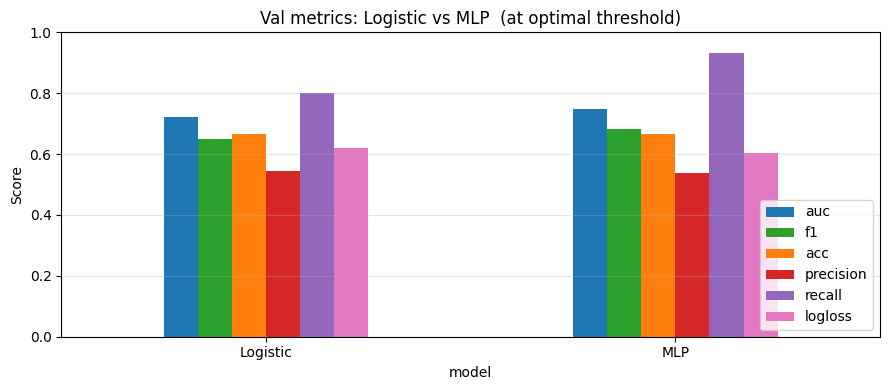


>>> Recommended model: MLP  (val AUC = 0.7472)


In [36]:
summary = pd.DataFrame([
    {"model": "Logistic", "split": "train", **m_train_log},
    {"model": "Logistic", "split": "val",   **m_val_log},
    {"model": "MLP",      "split": "train", **m_train_mlp},
    {"model": "MLP",      "split": "val",   **m_val_mlp},
])
cols = ["model", "split", "auc", "f1", "acc", "precision", "recall", "logloss"]
print("\n=== Final summary (metrics at optimal threshold) ===")
print(summary[cols].to_string(index=False))

val_summary = summary[summary["split"] == "val"].set_index("model")
metric_cols  = ["auc", "f1", "acc", "precision", "recall", "logloss"]
val_summary[metric_cols].plot(kind="bar", figsize=(9, 4), rot=0,
                               color=["tab:blue","tab:green","tab:orange","tab:red","tab:purple","tab:pink"])
plt.title("Val metrics: Logistic vs MLP  (at optimal threshold)")
plt.ylabel("Score"); plt.ylim(0, 1)
plt.legend(loc="lower right"); plt.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

# Triem el millor model final
best_model_name = val_summary["auc"].idxmax()
print(f"\n>>> Recommended model: {best_model_name}  "
      f"(val AUC = {val_summary.loc[best_model_name, 'auc']:.4f})")

Tot i obtenir mètriques bastant similars, podem observar que la **Val AUC**, la **VAL F1** i la **Val Recall** són superiors al MLP. Com estem treballant en un context clínic, aquestes mètriques són les que realment ens interessen ja que volem **minimitzar els falsos negatius**. És per això que el nostre model final seria un **MLP** amb els següents hiperparàmetres:
- `activation`: tanh

- `alpha`: 0.00010

- `batch_size`: 32

- `beta_1`: 0.80

- `beta_2`: 0.999

- `hidden_layer_sizes`: (64, 32)

- `learning_rate_init`: 0.0005

- `solver`: adam

## Exemple d'ús:

Per provar el model, simularem un pacient per veure quina és la seva predicció

In [37]:
x_new = np.array([[18.0, 160.0, 55.0, 85.0, 130.0]])  # fat, meat, stress, oxygen, sugar
p = best_mlp.predict_proba(x_new)[0, 1]
y_hat = int(p >= thr_mlp)
print(f"Probabilitat={p:.3f} | Predicció={y_hat} ({'Sí' if y_hat==1 else 'No'})")

Probabilitat=0.359 | Predicció=1 (Sí)
